# Monte Carlo sampling for asymmetric errors

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skewnorm
import os
import csv

data_directory = "/mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/CMBFeatureNet/data/"
os.chdir(data_directory)
print("Current working directory:", os.getcwd())

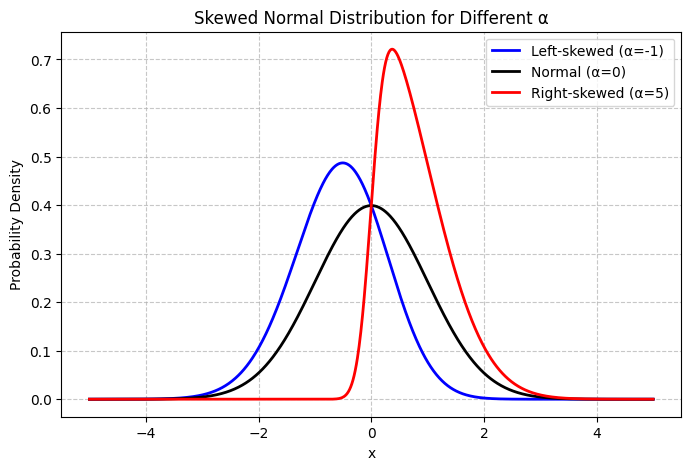

In [4]:
#Example for skewed normal distribution
x = np.linspace(-5, 5, 1000)

#Skewness parameters
alpha_values = [-1, 0, 5]  #Left-skewed, symmetric, right-skewed
colors = ['blue', 'black', 'red']
labels = ['Left-skewed (α=-1)', 'Normal (α=0)', 'Right-skewed (α=5)']

plt.figure(figsize=(8, 5))

for alpha, color, label in zip(alpha_values, colors, labels):
    pdf = skewnorm.pdf(x, alpha, loc=0, scale=1)  #Standard skew-normal
    plt.plot(x, pdf, color=color, label=label, linewidth=2)

plt.xlabel('x')
plt.ylabel('Probability Density')
plt.title('Skewed Normal Distribution for Different α')
plt.legend()
plt.grid(linestyle='--', alpha=0.7)
plt.show()

In [ ]:
#Planck TT data
base_path = "./experimental_data"
data_Planck = np.loadtxt(base_path +'/COM_PowerSpect_CMB-TT-full_R3.01.txt')
ls_Planck_TT = data_Planck[:, 0]
dl_Planck_TT = data_Planck[:, 1]
sdl_Planck_TT_neg = data_Planck[:, 2]
sdl_Planck_TT_pos = data_Planck[:, 3]
round_ls_Pl_TT = np.round(ls_Planck_TT)

#Planck TE data
data_Planck = np.loadtxt(base_path +'/COM_PowerSpect_CMB-TE-full_R3.01.txt')
ls_Planck_TE = data_Planck[:, 0]
dl_Planck_TE = data_Planck[:, 1]
sdl_Planck_TE_neg = data_Planck[:, 2]
sdl_Planck_TE_pos = data_Planck[:, 3]
round_ls_Pl_TE = np.round(ls_Planck_TE)

#Planck EE data
data_Planck = np.loadtxt(base_path +'/COM_PowerSpect_CMB-EE-full_R3.01.txt')
ls_Planck_EE = data_Planck[:, 0]
dl_Planck_EE = data_Planck[:, 1]
sdl_Planck_EE_neg = data_Planck[:, 2]
sdl_Planck_EE_pos = data_Planck[:, 3]
round_ls_Pl_EE = np.round(ls_Planck_EE)

## $\sigma_{\mathcal{C}_{\ell}^{TT}}$ sampling

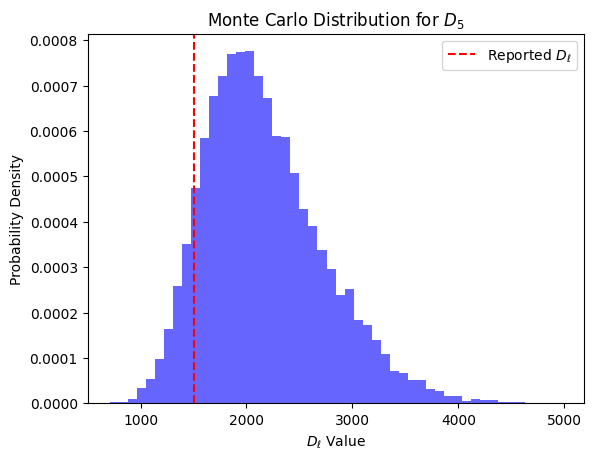

In [6]:
from CMBFeatureNet import covariance_asymmetric_errors
num_samples = 10000

#Generate Monte Carlo samples for each l
samples_dict_tt = {}
for i, l in enumerate(ls_Planck_TT):
    samples_dict_tt[l] =  covariance_asymmetric_errors(dl_Planck_TT[i], sdl_Planck_TT_neg[i], sdl_Planck_TT_pos[i], num_samples)

#Example: histogram for one multipole (l=5)
l_example = 5
plt.hist(samples_dict_tt[l_example], bins=50, density=True, alpha=0.6, color='b')
plt.axvline(dl_Planck_TT[ls_Planck_TT == l_example], color='r', linestyle='dashed', label="Reported $D_\ell$")
plt.xlabel("$D_\ell$ Value")
plt.ylabel("Probability Density")
plt.title(f"Monte Carlo Distribution for $D_{l_example}$")
plt.legend()
plt.show()

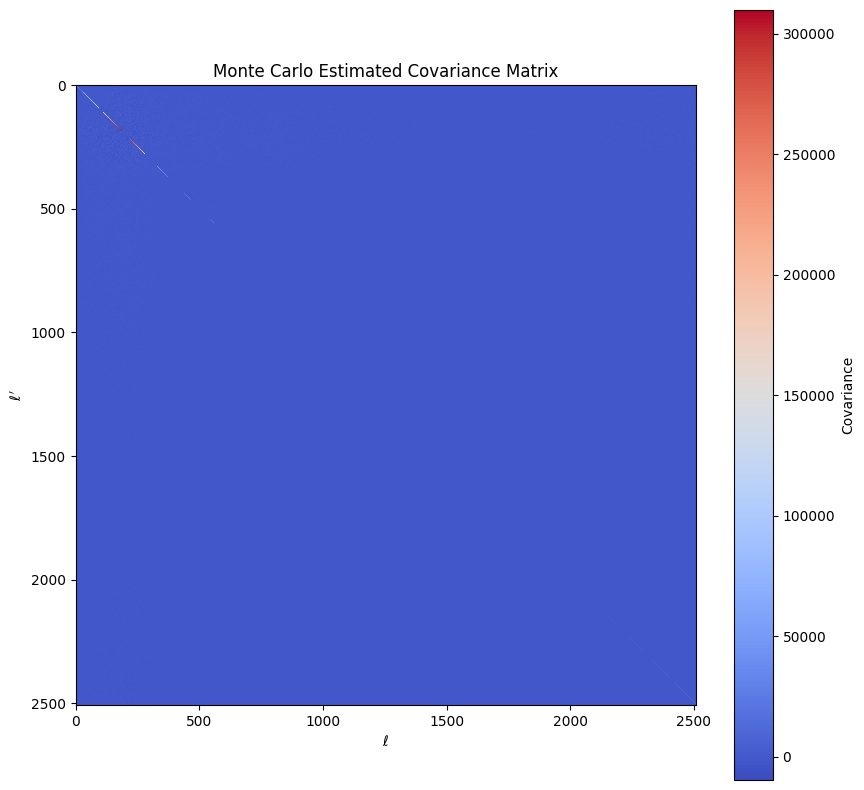

In [8]:
#Generate Monte Carlo samples for each l
samples_matrix_tt = np.zeros((num_samples, len(ls_Planck_TT)))  # Shape (num_samples, num_ls_Planck_TT)

for i, l in enumerate(ls_Planck_TT):
    samples_matrix_tt[:, i] = covariance_asymmetric_errors(dl_Planck_TT[i], sdl_Planck_TT_neg[i], sdl_Planck_TT_pos[i], num_samples)

#Compute the covariance matrices
cov_matx_tt = np.cov(samples_matrix_tt, rowvar=False)  #Covariance along columns (i.e., different l values)

#Plot covariance matrix (TT case)
plt.figure(figsize=(10,10))
plt.imshow(cov_matx_tt, cmap='coolwarm', interpolation='none')
plt.colorbar(label='Covariance')
plt.xlabel("$\ell$")
plt.ylabel("$\ell'$")
plt.title("Monte Carlo Estimated Covariance Matrix")
plt.show()

## $\sigma_{\mathcal{C}_{\ell}^{TE}}$ and $\sigma_{\mathcal{C}_{\ell}^{EE}}$ sampling

In [9]:
#Generate Monte Carlo samples for each l
samples_matrix_te = np.zeros((num_samples, len(ls_Planck_TE)))  #Shape (num_samples, num_ls_Planck_TT)
for i, l in enumerate(ls_Planck_TE):
    samples_matrix_te[:, i] = covariance_asymmetric_errors(dl_Planck_TE[i], sdl_Planck_TE_neg[i], sdl_Planck_TE_pos[i], num_samples)

samples_matrix_ee = np.zeros((num_samples, len(ls_Planck_EE)))  #Shape (num_samples, num_ls_Planck_TT)
for i, l in enumerate(ls_Planck_EE):
    samples_matrix_ee[:, i] = covariance_asymmetric_errors(dl_Planck_EE[i], sdl_Planck_EE_neg[i], sdl_Planck_EE_pos[i], num_samples)

cov_matx_te = np.cov(samples_matrix_te, rowvar=False)
cov_matx_ee = np.cov(samples_matrix_ee, rowvar=False)

In [ ]:
#Store the covariance matrices
base_pathCV = "./simulated_data/simulated_cov_matrices"

with open(base_pathCV + '/dlstt_cov_matx(mcmc).csv', 'w') as x:
    writer = csv.writer(x, delimiter=',',quoting=csv.QUOTE_NONNUMERIC)
    writer.writerows(cov_matx_tt)
x.close()

with open(base_pathCV + '/dlste_cov_matx(mcmc).csv', 'w') as x:
    writer = csv.writer(x, delimiter=',',quoting=csv.QUOTE_NONNUMERIC)
    writer.writerows(cov_matx_te)
x.close()

with open(base_pathCV + '/dlsee_cov_matx(mcmc).csv', 'w') as x:
    writer = csv.writer(x, delimiter=',',quoting=csv.QUOTE_NONNUMERIC)
    writer.writerows(cov_matx_ee)
x.close()